# Generating Points on the Flag Manifold

## Setup

In [1]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)
icdf_normal = torch.distributions.Normal(loc=torch.zeros(1,device=DEVICE),scale=torch.ones(1,device=DEVICE)).icdf

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


In [2]:
def kernel(x, y, lam, r, c):
    jvec = torch.arange(r+1,device=DEVICE)
    rt = jvec[-1]
    logcrj_term = torch.where(rt-jvec==0,torch.zeros_like(rt-jvec),(rt-jvec)*torch.log(c*torch.ones_like(rt)))
    logcomb = agsutil.logcomb(rt,jvec)+logcrj_term+2*jvec*torch.log(lam.sum(-1))-jvec*np.log(lam.size(-1))
    denom = torch.exp(logcomb).sum()
    v = (c+(x*y).sum((-2,-1)))**r/denom 
    return v
def opt_weights(x, lam, r, c):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:],lam,r,c) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat,upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w
# kernel(torch.rand(3,3),torch.rand(3,3),lam=torch.arange(1,6)/100,r=2,c=1)

## Transform and Generators

In [3]:
def tff_qr(u, lam):
    t = lam.size(-1)
    assert u.size(-1)==(t**2)
    assert (0<=u).all()
    assert (u<=1).all()
    u = u.reshape((*u.shape[:-1],t,t))
    v = icdf_normal(u)
    q,r = torch.linalg.qr(v)
    d = torch.diagonal(r,dim1=-2,dim2=-1).sign()
    q = q*d[...,None,:]
    assert torch.allclose(torch.einsum("...ij,...jk->...ik",q,r*d[...,:,None]),v)
    return q
def tff_eig(u, lam):
    t = lam.size(-1) 
    assert u.size(-1)==(t*(t+1)//2+t)
    alpha = icdf_normal(u[...,:t])
    beta = icdf_normal(u[...,t:(-t)])/np.sqrt(2)
    signs = torch.where(u[...,(-t):]>1/2,1.,-1.).to(DEVICE)
    il0,il1 = torch.tril_indices(t,t,offset=-1,device=DEVICE)
    v = torch.eye(t,device=DEVICE)*alpha[...,None]
    v[...,il0,il1] = beta
    v += v.tril(-1).transpose(dim0=-2,dim1=-1)
    assert torch.allclose(v[...,torch.arange(t,device=DEVICE),torch.arange(t,device=DEVICE)],alpha)
    gamma,q = torch.linalg.eigh(v)
    q = q*signs[...,None,:] # this is required because torch.eigh pins the sign to make the largest entry of each eigenvector positive
    assert torch.allclose(torch.einsum("...ij,...kj->...ik",q,q),torch.eye(t,device=DEVICE))
    assert torch.allclose(torch.einsum("...ij,...j,...kj->...ik",q,gamma,q),v)
    return q
def genf_qr_iid_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t**2),generator=rng,device=DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_qr_iid_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t**2),generator=rng,device=DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
def genf_qr_ld_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_qr_ld_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
def genf_eig_iid_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t*(t+1)//2+t),generator=rng,device=DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_eig_iid_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t*(t+1)//2+t),generator=rng,device=DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
def genf_eig_ld_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t*(t+1)//2+t,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_eig_ld_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t*(t+1)//2+t,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
# genf_qr_iid_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_qr_iid_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_qr_ld_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_qr_ld_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_iid_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_iid_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_ld_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_ld_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);

## Optimized Points and Weights

In [35]:
def genf_opt_x_w(
        n,
        lam,
        r,
        c,
        seed=None,
        verbose = None, 
        iters = 100,
        eps_kmat = 1e-8,
        verbose_indent = 4,
        ):
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_qr(u,lam)
    theta0 = agsutil.from_unitary(q)
    zerosn = torch.zeros(n,device=DEVICE)
    onesn = torch.ones(n,device=DEVICE)
    eyen = torch.eye(n,device=DEVICE)
    def discrepancy_loss(theta):
        q = agsutil.to_unitary(theta,t)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:],lam,r,c) # (n,n)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        # discrep = 1-(v**2).sum(-1)
        return v,x,L
    u,x,L = agsutil.lm_opt(
        f = discrepancy_loss,
        theta0 = theta0,
        ytrue = zerosn,
        iters = iters,
        verbose = verbose,
        verbose_indent = verbose_indent,
        loss_mult = -1,
        loss_shift = 1,
    )
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    return x,w
    
genf_opt_x_w(
    n = 2**4, 
    lam=torch.arange(1,4,dtype=float,device=DEVICE)/10,
    r = 3, 
    c = 0,
    seed = 17);

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 2.1e-02   | 2.1e-02   | 2.1e-02   | 2.1e-02   | 2.1e-02   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.0        
    5          | 1.7e-02   | 1.7e-02   | 1.7e-02   | 1.7e-02   | 1.7e-02   | 5.0e-07   | 5.0e-07   | 5.0e-07   | 5.0e-07   | 5.0e-07   | 1.0e+00   | 1.0e+00   | 1.0e+0

## Convergence on a Test Function

In [8]:
def ffunc_tmp(x):
    t = x.size(-1)
    assert x.shape[-2:]==(t,t)
    y = torch.linalg.matrix_norm(x,ord=-1)
    # y = (x**3).mean((-2,-1))
    return y
def ffunc_poly1(x):
    t = x.size(-1)
    assert x.shape[-2:]==(t,t)
    m1 = torch.arange(t**2,device=DEVICE).reshape((t,t))
    y = (m1*x).mean((-2,-1))
    return y
def ffunc_poly2(x):
    t = x.size(-1)
    assert x.shape[-2:]==(t,t)
    m2 = torch.arange(t**4,device=DEVICE).reshape((t**2,t**2))
    xf = x.flatten(start_dim=-2)
    y = (m2*xf[...,:,None]*xf[...,None,:]).mean((-2,-1))
    return y
def get_approx(ffunc, genf, n, lam, seed=None, verbose=None):
    x,w = genf(n=n,lam=lam,seed=seed,verbose=verbose)
    y = ffunc(x)
    muhat = (w*y).sum()
    return muhat 
ffunc = ffunc_poly2
lam = torch.tensor([1,1,2,2,3],device=DEVICE,dtype=float)
muref = get_approx(ffunc,genf_eig_ld_x_equal_w,n=2**19,lam=lam,seed=None,verbose=False)
n = 2**torch.arange(2,8)
print("muref = %.4e"%muref)
genf_funcs = [
    [r"QR IID $x$ equal $w$", genf_qr_iid_x_equal_w],
    [r"QR LD $x$ equal $w$", genf_qr_ld_x_equal_w],
    [r"Eig IID $x$ equal $w$", genf_eig_iid_x_equal_w],
    [r"Eig LD $x$ equal $w$", genf_eig_ld_x_equal_w],
    [r"Opt1 $(x,w)$", genf_opt1_x_w],
    # [r"Opt1 $x$, equal $w$", genf_opt1_x_equal_w],
    [r"Opt2 $(x,w)$", genf_opt2_x_w],
    # [r"Opt2 $x$, equal $w$", genf_opt2_x_equal_w],
    ]
trials = 5
seeds = [i for i in range(trials)]
errors = torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
for i,(key,genf) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            muhat = get_approx(ffunc,genf,n=n[j],lam=lam,seed=seeds[t],verbose=False)
            errors[i,j,t] = float(torch.abs(muhat-muref).cpu())
            print("        trial %-10d time %-10.1f muhat %-10.1e error %-10.1e"%(t,time.perf_counter()-t0,muhat,errors[i,j,t]))
            if "CUDA" in DEVICE: torch.cuda.empty_cache()

muref = 4.2452e+01
QR IID $x$ equal $w$
    n = 4
        trial 0          time 0.0        muhat 4.2e+01    error 6.3e-01   
        trial 1          time 0.0        muhat 3.4e+01    error 8.6e+00   
        trial 2          time 0.0        muhat 4.6e+01    error 3.8e+00   
        trial 3          time 0.0        muhat 5.1e+01    error 8.9e+00   
        trial 4          time 0.0        muhat 4.8e+01    error 5.2e+00   
    n = 8
        trial 0          time 0.0        muhat 4.7e+01    error 4.1e+00   
        trial 1          time 0.0        muhat 3.4e+01    error 8.7e+00   
        trial 2          time 0.0        muhat 4.1e+01    error 1.5e+00   
        trial 3          time 0.0        muhat 5.3e+01    error 1.1e+01   
        trial 4          time 0.0        muhat 4.5e+01    error 2.5e+00   
    n = 16
        trial 0          time 0.0        muhat 4.1e+01    error 1.0e+00   
        trial 1          time 0.0        muhat 3.7e+01    error 5.8e+00   
        trial 2          time

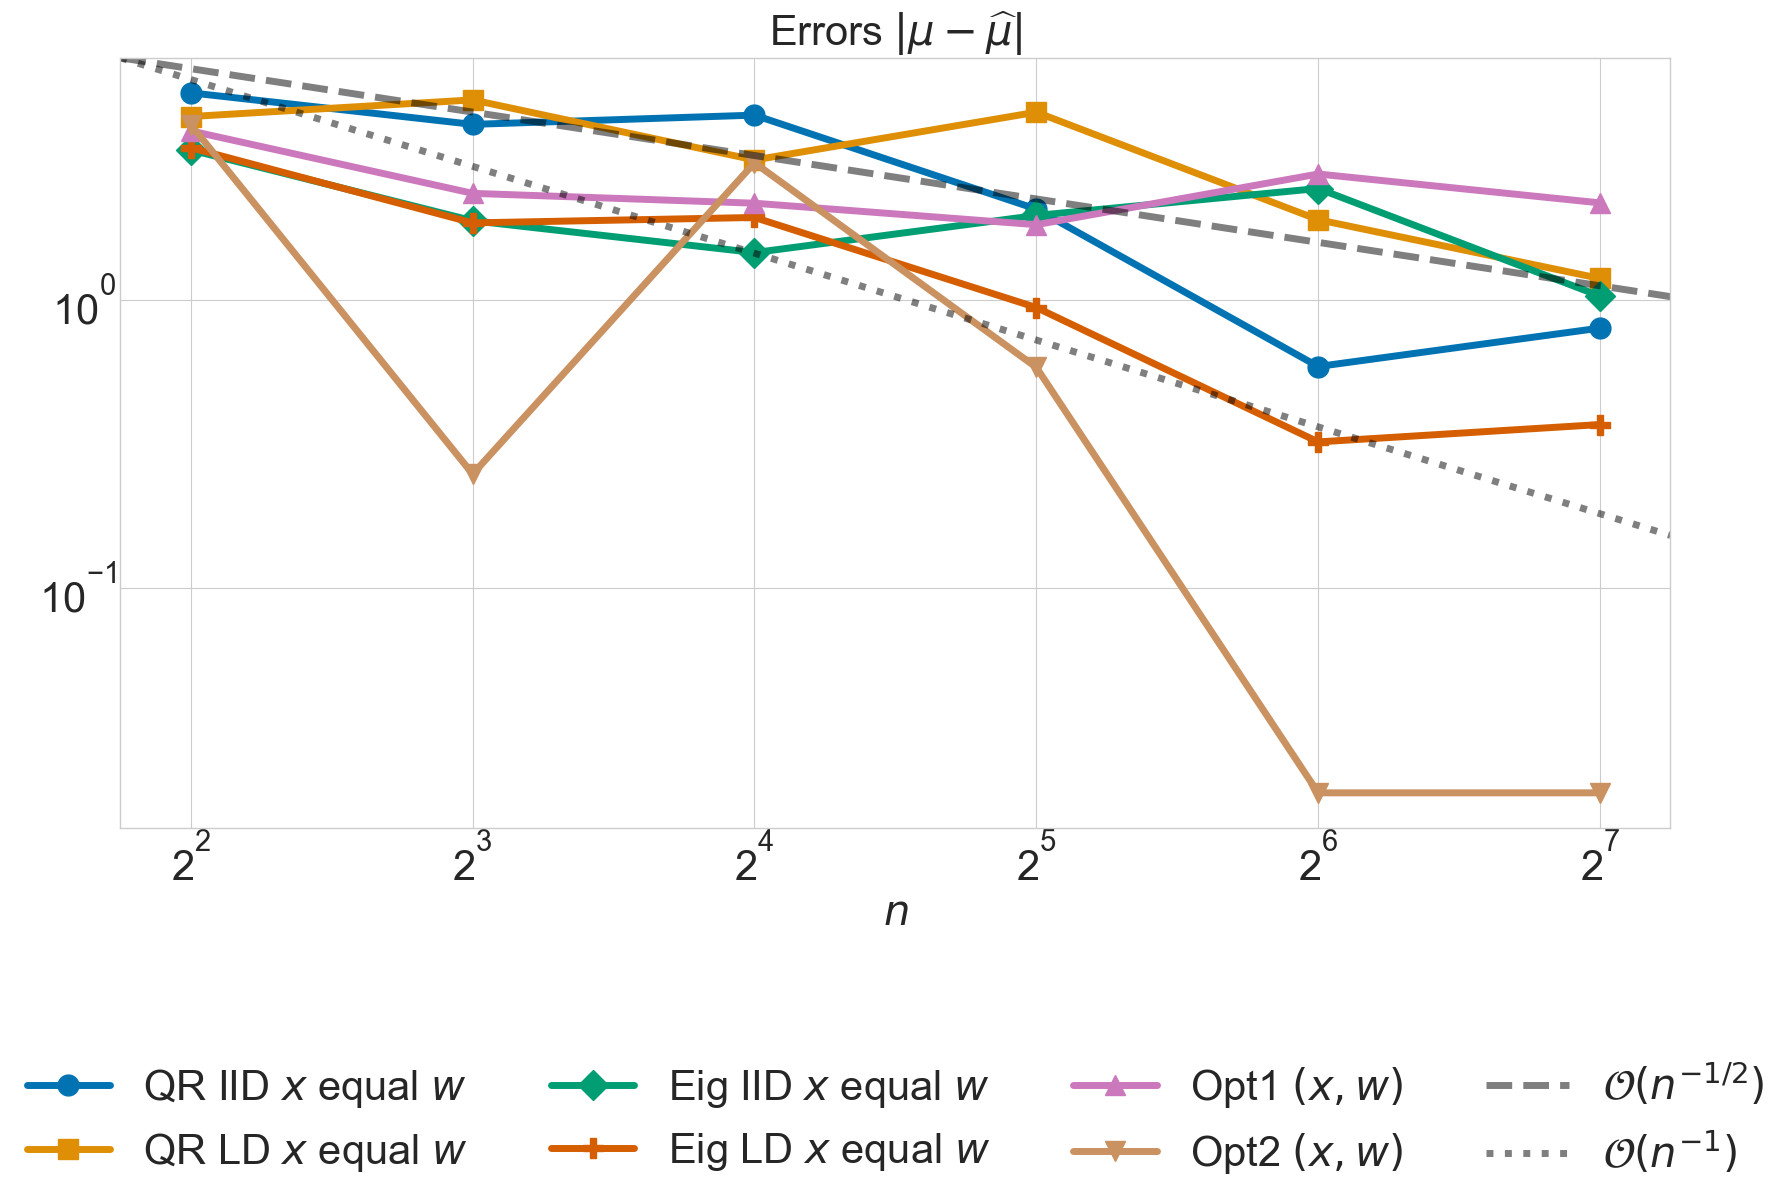

In [9]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/2/1.5),sharex=True,sharey=False)
for i,(key,sphere_func) in enumerate(genf_funcs):
    ax.plot(n,errors[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = ax.get_xlim()
ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-1)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.5))
ax.set_title(r"Errors $|\mu - \widehat{\mu}|$")
ax.set_xlabel(r"$n$");

In [10]:
errors_df = pd.DataFrame(errors.median(-1).values.T,columns=[name for (name,func) in genf_funcs])
errors_df['n'] = n
errors_df.set_index('n')
errors_df

,QR IID $x$ equal $w$,QR LD $x$ equal $w$,Eig IID $x$ equal $w$,Eig LD $x$ equal $w$,"Opt1 $(x,w)$","Opt2 $(x,w)$",n
0,5.218786,4.319879,3.306589,3.366530,3.850708,4.043689,4
1,4.057151,4.932928,1.879900,1.847967,2.339451,0.248926,8
2,4.367991,3.053255,1.458094,1.929758,2.162389,2.985277,16
3,2.062953,4.472032,1.961300,0.940440,1.821725,0.583236,32
4,0.587233,1.896098,2.431748,0.321668,2.730030,0.019538,64
5,0.797982,1.185902,1.030319,0.369512,2.168114,0.019538,128
